In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# red wine 품질 등급 예측
```
1. 데이터 셋 확보 & 전처리
    결측치 처리 -> 독립(입력)변수와 종속(타겟)변수를 분리 ->독립변수의 스케일 조정(StandardScaler) 
    -> 종속변수의 균형을 확인
    -> 종속변수 원핫인코딩(pd.get_dummies) -> 훈련셋과 테스트셋분리(train_test_split)
2. 모델구성
3. 모델학습과정 설정(다중분류)
4. 모델학습(callbacks, compute_class_weight를 이용)
5. 모델평가(시각화, 평가, 교차표 - 테스트셋)
6. 모델 저장 / 예측
    
```

In [56]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU, Dropout
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras import metrics  
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback, ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical # 원핫인코딩(pd.get dummies)

# 1. 데이터셋 확보 및 전처리

In [13]:
redwine=pd.read_csv('data/winequality-red.csv',sep=';')

In [14]:
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
468,11.4,0.36,0.69,2.1,0.09,6.0,21.0,1.0,3.17,0.62,9.2,6


In [15]:
redwine.info()
redwine

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
#redwine=np.loadtxt('data/winequality-red.csv',delimiter=';',skiprows=1) 넘파이배열
# 결측치 처리가 어려워 dataframe으로 분석

In [27]:
#독립(입력)변수와 종속(타겟)변수를 분리
X_redwine=redwine.iloc[:,:-1].values   #또는 .to_numpy() numpy배열로 변경
y_redwine=redwine.iloc[:,-1]
X_redwine.shape,y_redwine.shape

((1599, 11), (1599,))

In [32]:
#독립변수의 스케일조정
scaler =StandardScaler()
scaled_X_redwine = scaler.fit_transform(X_redwine)

In [40]:
#종속변수의 원핫인코딩
Y_redwine = pd.get_dummies(y_redwine) #.values
np.c_[y_redwine[2:4],Y_redwine[2:4]] #원데이터와 원핫인코딩 

array([[5, 0, 0, 1, 0, 0, 0],
       [6, 0, 0, 0, 1, 0, 0]], dtype=int64)

In [43]:
# 종속변수의 균형을 확인
y_redwine.value_counts(normalize=True)

5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: quality, dtype: float64

In [44]:
#독립변수와 타겟변수
scaled_X_redwine.shape, Y_redwine.shape

((1599, 11), (1599, 6))

In [58]:
# 훈련셋과 테스트셋 분리(층화추출) = 7:3
X_train, X_test, Y_train, Y_test =train_test_split(scaled_X_redwine,Y_redwine,
                                                   test_size=0.3,
                                                   stratify=Y_redwine, # 층화추출
                                                   random_state=12) # seed값

In [62]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1119, 11), (480, 11), (1119, 6), (480, 6))

# 2. 모델구성
- 입력 11 -> 64 -> 50 -> 30 -> 출력6
- HeNormal 초기화 : 층이 깊을 때 활성화함수를 relu사용시 모델이 좀더 안정정으로 필요없는 부분을 초기화한다

In [63]:
model = Sequential(name='sequential')
model.add(Input(11))
model.add(Dense(units=64, activation='relu', kernel_initializer=HeNormal(seed=42)))
model.add(Dense(units=50, activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(units=50, activation='relu',kernel_initializer='he_normal'))
model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 64)                768       
                                                                 
 dense_13 (Dense)            (None, 50)                3250      
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_14 (Dense)            (None, 50)                2550      
                                                                 
 dense_15 (Dense)            (None, 6)                 306       
                                                                 
Total params: 6,874
Trainable params: 6,874
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [64]:
model.compile(loss='categorical_crossentropy', #원핫인코딩을 안했을때 sparse_categorical_crossentropy사용
              optimizer='adam', metrics=['accuracy',
                                         metrics.Recall(name='recall'),
                                         metrics.Precision(name='precision')])

# 4. 학습시키기
- callbacks 이용

In [70]:
%%time
earlyStopping=EarlyStopping(monitor='val_loss', patience=10)

hist =model.fit(X_train, Y_train, validation_split=0.2, #학습셋의 20%를 검증셋으로
                #class_weight=class_weight_dict, 를 지정하지 않고 학습할 예정()
                callbacks=[earlyStopping],
                epochs=100,
                verbose=2,
               )

Epoch 1/100
28/28 - 0s - loss: 0.7669 - accuracy: 0.6905 - recall: 0.5933 - precision: 0.7294 - val_loss: 1.0369 - val_accuracy: 0.5491 - val_recall: 0.5000 - val_precision: 0.5685 - 165ms/epoch - 6ms/step
Epoch 2/100
28/28 - 0s - loss: 0.7538 - accuracy: 0.6760 - recall: 0.5989 - precision: 0.7128 - val_loss: 1.0478 - val_accuracy: 0.5580 - val_recall: 0.5045 - val_precision: 0.5765 - 107ms/epoch - 4ms/step
Epoch 3/100
28/28 - 0s - loss: 0.7295 - accuracy: 0.6961 - recall: 0.6246 - precision: 0.7298 - val_loss: 1.0222 - val_accuracy: 0.5625 - val_recall: 0.5179 - val_precision: 0.5949 - 95ms/epoch - 3ms/step
Epoch 4/100
28/28 - 0s - loss: 0.7332 - accuracy: 0.6927 - recall: 0.6212 - precision: 0.7325 - val_loss: 1.0216 - val_accuracy: 0.5580 - val_recall: 0.5179 - val_precision: 0.5771 - 117ms/epoch - 4ms/step
Epoch 5/100
28/28 - 0s - loss: 0.7213 - accuracy: 0.6905 - recall: 0.6391 - precision: 0.7268 - val_loss: 1.0270 - val_accuracy: 0.5804 - val_recall: 0.5089 - val_precision: 0.6

# 5. 모델평가
- 시각화, 평가, 교차표

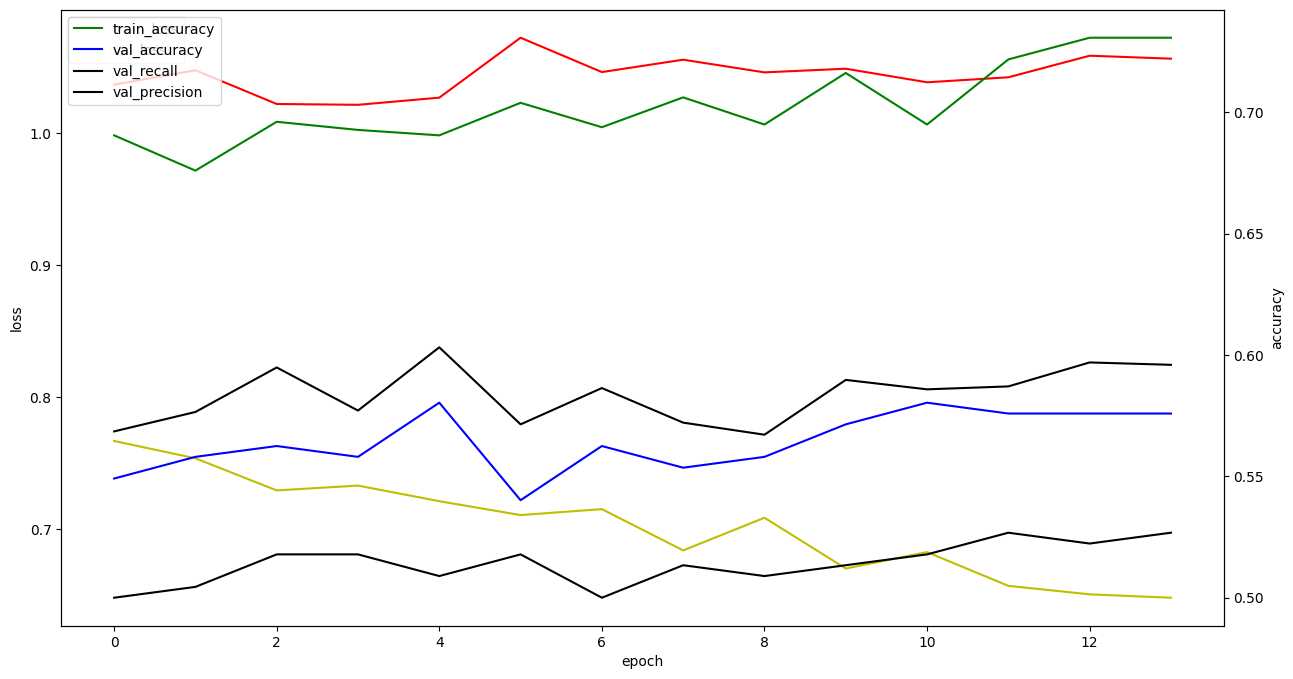

loss: 1.0196468830108643
accuracy: 0.625


In [74]:
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')
acc_ax.plot(hist.history['val_precision'],'k',label='val_precision')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()
# 모델평가(시험셋=test셋)
loss_metrics=model.evaluate(X_test, Y_test,batch_size=100, verbose=0)
print('loss:', loss_metrics[0])
print('accuracy:', loss_metrics[1])

In [72]:
#평가
loss, acc, recall, precision =model.evaluate(X_test,Y_test, verbose=0)
print('정확도:', acc)
print('재현율:',recall)
print('정밀도:',precision)

정확도: 0.625
재현율: 0.5583333373069763
정밀도: 0.6350710988044739


In [94]:
#교차표를 위한 y_hat
# get dummies를 사용했었기에 복잡하다 -> 0,1,2 등급이 없어지면서 2로 출력되는걸 5로 offset해줘야함
y_hat = model.predict(X_test).argmax(axis=1) +3
y = Y_test.values.argmax(axis=1) + 3
pd.crosstab(y,y_hat,rownames=['실제값'],colnames=['예측값'])

15/15 [==============================] - 0s 2ms/step


예측값,3,4,5,6,7
실제값,,,,,
3,0,0,2,1,0
4,1,0,10,4,1
5,0,0,143,56,5
6,0,1,43,133,15
7,0,0,3,33,24
8,0,0,0,2,3


# 6. 모델 사용

In [98]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [99]:
data =[[ 7.4,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ]]

In [102]:
model.predict(scaler.transform(data)).argmax(axis=1)+3

1/1 [==============================] - 0s 29ms/step


array([5], dtype=int64)